In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import networkx as nx
from itertools import combinations
import re
import warnings
warnings.filterwarnings('ignore')


# Load the relevant papers dataset

In [4]:
# Load the relevant papers dataset
df = pd.read_csv('relevant_papers.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()


Dataset shape: (863, 15)

Column names:
['doi', 'title', 'authors', 'author_count', 'year', 'month', 'journal', 'publisher', 'abstract', 'subjects', 'type', 'url', 'source', 'relevance_score', 'relevance_flags']

First few rows:


,doi,title,authors,author_count,year,month,journal,publisher,abstract,subjects,type,url,source,relevance_score,relevance_flags
0,10.51583/ijltemas.2025.1413sp041,Survival Analysis of Customer Lifetime and Chu...,Akshata Lembhe; Yogita Lagad; Rupali Kamthe; A...,4,2025,10.0,International Journal of Latest Technology in ...,RSIS International,<jats:p>Abstract: Customer churn poses a signi...,NaN,journal-article,https://doi.org/10.51583/ijltemas.2025.1413sp041,CrossRef,14,survival:survival analysis; survival:cox propo...
1,NaN,Estimating Heterogenous Treatment Effects for ...,Guanghui Pan,1,2024,9,arXiv,arXiv,"In this paper, we introduce a doubly doubly ro...",econ.GN; stat.AP,preprint,http://arxiv.org/abs/2409.01412v1,arXiv,12,survival:survival analysis; survival:cox propo...
2,NaN,e-Profits: A Business-Aligned Evaluation Metri...,Awais Manzoor; M. Atif Qureshi; Etain Kidney; ...,4,2025,7,arXiv,arXiv,Retention campaigns in customer relationship m...,cs.LG,preprint,http://arxiv.org/abs/2507.08860v2,arXiv,10,survival:survival analysis; survival:kaplan-me...
3,10.35774/econa2025.01.112,Survival analysis as a tool for predicting and...,Yurii Kleban; Viktoriia Mazurenko,2,2025,NaN,Economic Analysis,West Ukrainian National University,<jats:p>Introduction. Customer churn is one of...,NaN,journal-article,https://doi.org/10.35774/econa2025.01.112,CrossRef,10,survival:survival analysis; survival:cox propo...
4,10.55640/ijaair-v02i05-01,LEVERAGING DEEP LEARNING IN SURVIVAL ANALYSIS ...,Dr. Kenji Yamamoto; Prof. Lijuan Wang,2,2025,5.0,International Journal of Advanced Artificial I...,European International Journal of Multidiscipl...,<jats:p>Survival analysis is a critical statis...,NaN,journal-article,https://doi.org/10.55640/ijaair-v02i05-01,CrossRef,10,survival:survival analysis; survival:survival ...


# Check data quality - how many papers have abstracts and relevance_flags

In [5]:
# Check data quality - how many papers have abstracts and relevance_flags
print("Papers with abstracts:", df['abstract'].notna().sum())
print("Papers without abstracts:", df['abstract'].isna().sum())
print("\nPapers with relevance_flags:", df['relevance_flags'].notna().sum())
print("Papers without relevance_flags:", df['relevance_flags'].isna().sum())

# Look at some examples of relevance_flags
print("\n--- Sample relevance flags ---")
for i in range(min(5, len(df))):
    if pd.notna(df.iloc[i]['relevance_flags']):
        print(f"\nPaper {i+1}: {df.iloc[i]['title'][:80]}...")
        print(f"Flags: {df.iloc[i]['relevance_flags']}")


Papers with abstracts: 348
Papers without abstracts: 515

Papers with relevance_flags: 863
Papers without relevance_flags: 0

--- Sample relevance flags ---

Paper 1: Survival Analysis of Customer Lifetime and Churn Prediction in the Telecom Indus...
Flags: survival:survival analysis; survival:cox proportional hazard; survival:kaplan-meier; survival:survival function; forecasting:customer churn; forecasting:churn prediction; forecasting:customer lifetime

Paper 2: Estimating Heterogenous Treatment Effects for Survival Data with Doubly Doubly R...
Flags: survival:survival analysis; survival:cox proportional hazard; survival:survival function; causal:causal inference; causal:counterfactual; causal:treatment effect

Paper 3: e-Profits: A Business-Aligned Evaluation Metric for Profit-Sensitive Customer Ch...
Flags: survival:survival analysis; survival:kaplan-meier; forecasting:customer churn; forecasting:churn prediction; forecasting:customer lifetime

Paper 4: Survival analysis as a tool 

# Filter to papers with abstracts for more accurate co-occurrence analysis

In [6]:
# Filter to papers with abstracts for more accurate co-occurrence analysis
df_with_abstract = df[df['abstract'].notna()].copy()
print(f"Working with {len(df_with_abstract)} papers that have abstracts")

# Parse relevance flags to extract keywords
def parse_relevance_flags(flag_string):
    """Extract individual keywords from relevance_flags"""
    if pd.isna(flag_string):
        return []
    
    keywords = []
    # Split by semicolon
    flags = flag_string.split(';')
    for flag in flags:
        flag = flag.strip()
        # Extract the keyword after the colon
        if ':' in flag:
            keyword = flag.split(':', 1)[1].strip()
            keywords.append(keyword)
    return keywords

# Extract keywords for all papers
df_with_abstract['keywords'] = df_with_abstract['relevance_flags'].apply(parse_relevance_flags)

# Count total keyword occurrences
all_keywords = []
for keywords in df_with_abstract['keywords']:
    all_keywords.extend(keywords)

keyword_counts = Counter(all_keywords)
print(f"\nTotal unique keywords: {len(keyword_counts)}")
print("\nTop 20 most frequent keywords:")
for keyword, count in keyword_counts.most_common(20):
    print(f"  {keyword}: {count}")


Working with 348 papers that have abstracts

Total unique keywords: 32

Top 20 most frequent keywords:
  survival analysis: 86
  causal inference: 78
  cox proportional hazard: 56
  customer churn: 39
  customer lifetime: 33
  time-to-event: 33
  granger causality: 30
  demand forecast: 29
  survival model: 28
  churn prediction: 24
  customer retention: 22
  counterfactual: 20
  treatment effect: 16
  cox regression: 15
  demand prediction: 14
  kaplan-meier: 13
  hazard function: 13
  causal model: 12
  censored data: 11
  survival function: 8


# Build co-occurrence matrix

In [7]:
# Build co-occurrence matrix
# For each paper, every pair of keywords co-occurs
co_occurrence = defaultdict(int)

for keywords in df_with_abstract['keywords']:
    # Generate all unique pairs of keywords in this paper
    if len(keywords) >= 2:
        for pair in combinations(sorted(keywords), 2):
            co_occurrence[pair] += 1

print(f"Total co-occurrence pairs: {len(co_occurrence)}")

# Convert to list for analysis
co_occurrence_list = [(k1, k2, count) for (k1, k2), count in co_occurrence.items()]
co_occurrence_df = pd.DataFrame(co_occurrence_list, columns=['keyword1', 'keyword2', 'weight'])
co_occurrence_df = co_occurrence_df.sort_values('weight', ascending=False)

print("\nTop 20 co-occurrences:")
print(co_occurrence_df.head(20).to_string(index=False))


Total co-occurrence pairs: 135

Top 20 co-occurrences:
               keyword1           keyword2  weight
cox proportional hazard  survival analysis      28
       churn prediction     customer churn      22
      survival analysis     survival model      17
      survival analysis      time-to-event      15
       causal inference     counterfactual      15
cox proportional hazard      time-to-event      14
       causal inference   treatment effect      12
      customer lifetime customer retention      11
           kaplan-meier  survival analysis      11
         customer churn customer retention      10
          censored data  survival analysis       9
         survival model      time-to-event       8
cox proportional hazard     survival model       8
cox proportional hazard       kaplan-meier       8
         customer churn  survival analysis       8
          deep survival  survival analysis       7
           causal model  structural causal       7
       causal inference    

# Categorize keywords into methods and applications to examine the hypothesis

In [8]:
# Categorize keywords into methods and applications to examine the hypothesis
# Methods: survival methods and causal methods
# Applications: forecasting/business applications

survival_methods = [
    'cox proportional hazard', 'kaplan-meier', 'survival model', 
    'cox regression', 'hazard function', 'survival function', 
    'deep survival', 'survival tree', 'weibull', 'accelerated failure time',
    'random survival forest'
]

causal_methods = [
    'causal inference', 'counterfactual', 'treatment effect', 
    'granger causality', 'causal model', 'structural causal',
    'propensity score', 'instrumental variable'
]

applications = [
    'customer churn', 'churn prediction', 'customer lifetime', 
    'customer retention', 'demand forecast', 'demand prediction',
    'sales forecast', 'sales forecasting', 'inventory', 
    'supply chain', 'revenue forecast'
]

def categorize_keyword(keyword):
    if keyword in survival_methods:
        return 'survival_method'
    elif keyword in causal_methods:
        return 'causal_method'
    elif keyword in applications:
        return 'application'
    elif keyword in ['survival analysis', 'time-to-event', 'censored data']:
        return 'survival_concept'
    else:
        return 'other'

# Add categories to co-occurrence dataframe
co_occurrence_df['cat1'] = co_occurrence_df['keyword1'].apply(categorize_keyword)
co_occurrence_df['cat2'] = co_occurrence_df['keyword2'].apply(categorize_keyword)

# Focus on method-application pairs
method_app_pairs = co_occurrence_df[
    ((co_occurrence_df['cat1'].isin(['survival_method', 'causal_method'])) & 
     (co_occurrence_df['cat2'] == 'application')) |
    ((co_occurrence_df['cat2'].isin(['survival_method', 'causal_method'])) & 
     (co_occurrence_df['cat1'] == 'application'))
].copy()

print("Method-Application Co-occurrences:")
print(method_app_pairs.sort_values('weight', ascending=False).to_string(index=False))


Method-Application Co-occurrences:
               keyword1                keyword2  weight            cat1            cat2
       causal inference         demand forecast       3   causal_method     application
         customer churn            kaplan-meier       3     application survival_method
      customer lifetime            kaplan-meier       2     application survival_method
         customer churn       survival function       2     application survival_method
cox proportional hazard          customer churn       2 survival_method     application
       churn prediction            kaplan-meier       2     application survival_method
cox proportional hazard       customer lifetime       1 survival_method     application
           causal model         demand forecast       1   causal_method     application
         counterfactual         demand forecast       1   causal_method     application
       causal inference       customer lifetime       1   causal_method     applicati

# Examine specific hypothesis examples:

In [9]:
# Examine specific hypothesis examples:
# 1. Deep survival with customer churn vs sales forecasting
# 2. Granger causality with time-series forecasting

print("=== Testing Specific Hypothesis Examples ===\n")

# Deep survival connections
deep_survival_pairs = co_occurrence_df[
    (co_occurrence_df['keyword1'] == 'deep survival') | 
    (co_occurrence_df['keyword2'] == 'deep survival')
]
print("Deep survival co-occurrences:")
print(deep_survival_pairs[['keyword1', 'keyword2', 'weight']].to_string(index=False))

# Granger causality connections
print("\n" + "="*60 + "\n")
granger_pairs = co_occurrence_df[
    (co_occurrence_df['keyword1'] == 'granger causality') | 
    (co_occurrence_df['keyword2'] == 'granger causality')
]
print("Granger causality co-occurrences:")
print(granger_pairs[['keyword1', 'keyword2', 'weight']].to_string(index=False))


=== Testing Specific Hypothesis Examples ===

Deep survival co-occurrences:
               keyword1          keyword2  weight
          deep survival survival analysis       7
          deep survival     time-to-event       4
cox proportional hazard     deep survival       4
          deep survival           patient       4
          deep survival      kaplan-meier       3
          deep survival    survival model       2


Granger causality co-occurrences:
         keyword1          keyword2  weight
 causal inference granger causality       2
granger causality structural causal       1
  causal analysis granger causality       1
  demand forecast granger causality       1
   counterfactual granger causality       1


# Check for sales forecasting mentions

In [10]:
# Check for sales forecasting mentions
sales_keywords = co_occurrence_df[
    (co_occurrence_df['keyword1'].str.contains('sales', case=False, na=False)) | 
    (co_occurrence_df['keyword2'].str.contains('sales', case=False, na=False))
]
print("Sales-related co-occurrences:")
if len(sales_keywords) > 0:
    print(sales_keywords[['keyword1', 'keyword2', 'weight']].to_string(index=False))
else:
    print("No sales-related keywords found in co-occurrence pairs")

# Check raw keyword list for any sales mentions
print("\n" + "="*60 + "\n")
print("All unique keywords containing 'sales' or 'forecast':")
sales_or_forecast = [k for k in keyword_counts.keys() if 'sales' in k.lower() or 'forecast' in k.lower()]
for k in sales_or_forecast:
    print(f"  {k}: {keyword_counts[k]}")


Sales-related co-occurrences:
          keyword1       keyword2  weight
customer retention sales forecast       1
 demand prediction sales forecast       1
   demand forecast sales forecast       1


All unique keywords containing 'sales' or 'forecast':
  demand forecast: 29
  sales forecast: 3
  supply chain forecast: 1


# Build a network graph for visualization

In [11]:
# Build a network graph for visualization
# Focus on keywords that appear at least 5 times to keep the network readable

min_keyword_freq = 5
filtered_keywords = [k for k, count in keyword_counts.items() if count >= min_keyword_freq]

print(f"Filtered to {len(filtered_keywords)} keywords appearing >= {min_keyword_freq} times")
print("\nFiltered keywords:")
for k in sorted(filtered_keywords):
    print(f"  {k}: {keyword_counts[k]}")

# Filter co-occurrences to only include these keywords
filtered_co_occurrence = co_occurrence_df[
    (co_occurrence_df['keyword1'].isin(filtered_keywords)) & 
    (co_occurrence_df['keyword2'].isin(filtered_keywords))
].copy()

print(f"\nFiltered co-occurrence edges: {len(filtered_co_occurrence)}")


Filtered to 25 keywords appearing >= 5 times

Filtered keywords:
  causal analysis: 5
  causal discovery: 6
  causal inference: 78
  causal model: 12
  censored data: 11
  churn prediction: 24
  counterfactual: 20
  cox proportional hazard: 56
  cox regression: 15
  customer churn: 39
  customer lifetime: 33
  customer retention: 22
  deep survival: 7
  demand forecast: 29
  demand prediction: 14
  granger causality: 30
  hazard function: 13
  kaplan-meier: 13
  patient: 7
  structural causal: 8
  survival analysis: 86
  survival function: 8
  survival model: 28
  time-to-event: 33
  treatment effect: 16

Filtered co-occurrence edges: 107


# Create network graph

In [12]:
# Create network graph
G = nx.Graph()

# Add nodes with size based on frequency
for keyword in filtered_keywords:
    G.add_node(keyword, weight=keyword_counts[keyword])

# Add edges with weight based on co-occurrence
for _, row in filtered_co_occurrence.iterrows():
    G.add_edge(row['keyword1'], row['keyword2'], weight=row['weight'])

print(f"Network statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.3f}")
print(f"  Connected components: {nx.number_connected_components(G)}")

# Identify node categories for coloring
node_colors = []
node_categories = {}
for node in G.nodes():
    cat = categorize_keyword(node)
    node_categories[node] = cat
    if cat == 'survival_method':
        node_colors.append('#FF6B6B')  # Red
    elif cat == 'causal_method':
        node_colors.append('#4ECDC4')  # Teal
    elif cat == 'application':
        node_colors.append('#FFE66D')  # Yellow
    elif cat == 'survival_concept':
        node_colors.append('#FFA07A')  # Light salmon
    else:
        node_colors.append('#95E1D3')  # Light teal

print("\nNode categories:")
for cat in ['survival_method', 'causal_method', 'application', 'survival_concept', 'other']:
    nodes_in_cat = [n for n, c in node_categories.items() if c == cat]
    if nodes_in_cat:
        print(f"  {cat}: {len(nodes_in_cat)} nodes")


Network statistics:
  Nodes: 25
  Edges: 107
  Density: 0.357
  Connected components: 1

Node categories:
  survival_method: 7 nodes
  causal_method: 6 nodes
  application: 6 nodes
  survival_concept: 3 nodes
  other: 3 nodes


# Calculate network centrality measures to identify key concepts

In [13]:
# Calculate network centrality measures to identify key concepts
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')
closeness_centrality = nx.closeness_centrality(G, distance='weight')

# Create centrality dataframe
centrality_df = pd.DataFrame({
    'keyword': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': list(betweenness_centrality.values()),
    'closeness_centrality': list(closeness_centrality.values()),
    'frequency': [keyword_counts[k] for k in degree_centrality.keys()],
    'category': [node_categories[k] for k in degree_centrality.keys()]
}).sort_values('degree_centrality', ascending=False)

print("Top 15 keywords by degree centrality (most connected):")
print(centrality_df.head(15).to_string(index=False))


Top 15 keywords by degree centrality (most connected):
                keyword  degree_centrality  betweenness_centrality  closeness_centrality  frequency         category
      survival analysis           0.708333                0.000000              0.320000         86 survival_concept
cox proportional hazard           0.708333                0.058325              0.375000         56  survival_method
      survival function           0.583333                0.312235              0.470588          8  survival_method
       causal inference           0.541667                0.051265              0.380952         78    causal_method
          time-to-event           0.541667                0.013647              0.358209         33 survival_concept
         survival model           0.500000                0.142202              0.387097         28  survival_method
           kaplan-meier           0.500000                0.035237              0.369231         13  survival_method
         

# Compute specific method-application associations to test hypothesis

In [14]:
# Compute specific method-application associations to test hypothesis
# For each method, count co-occurrences with different applications

methods_of_interest = [
    'deep survival', 'cox proportional hazard', 'granger causality', 
    'kaplan-meier', 'survival model'
]

applications_of_interest = [
    'customer churn', 'churn prediction', 'customer lifetime', 
    'customer retention', 'demand forecast', 'demand prediction'
]

print("Method-Application Association Matrix:")
print("="*80)

association_matrix = []
for method in methods_of_interest:
    row = {'method': method}
    for app in applications_of_interest:
        # Find co-occurrence count
        cooc = filtered_co_occurrence[
            ((filtered_co_occurrence['keyword1'] == method) & (filtered_co_occurrence['keyword2'] == app)) |
            ((filtered_co_occurrence['keyword2'] == method) & (filtered_co_occurrence['keyword1'] == app))
        ]
        count = cooc['weight'].sum() if len(cooc) > 0 else 0
        row[app] = int(count)
    association_matrix.append(row)

assoc_df = pd.DataFrame(association_matrix)
print(assoc_df.to_string(index=False))

print("\n" + "="*80)
print("\nKey findings:")
print("- Deep survival appears 0 times with customer churn/churn prediction")
print("- Cox proportional hazard appears 2+1=3 times with customer churn/churn prediction")
print("- Granger causality appears 1 time with demand forecast")


Method-Application Association Matrix:
                 method  customer churn  churn prediction  customer lifetime  customer retention  demand forecast  demand prediction
          deep survival               0                 0                  0                   0                0                  0
cox proportional hazard               2                 1                  1                   1                0                  0
      granger causality               0                 0                  0                   0                1                  0
           kaplan-meier               3                 2                  2                   1                0                  0
         survival model               1                 0                  0                   0                0                  0


Key findings:
- Deep survival appears 0 times with customer churn/churn prediction
- Cox proportional hazard appears 2+1=3 times with customer churn/churn predic

# Check what deep survival actually co-occurs with

In [15]:
# Check what deep survival actually co-occurs with
print("Complete deep survival co-occurrence profile:")
deep_survival_full = co_occurrence_df[
    (co_occurrence_df['keyword1'] == 'deep survival') | 
    (co_occurrence_df['keyword2'] == 'deep survival')
].sort_values('weight', ascending=False)

for _, row in deep_survival_full.iterrows():
    k1 = row['keyword1']
    k2 = row['keyword2']
    other_keyword = k2 if k1 == 'deep survival' else k1
    print(f"  deep survival <-> {other_keyword}: {row['weight']}")

print("\nNote: 'patient' appears 4 times - this may indicate medical domain papers")

# Check the actual papers with deep survival
print("\n" + "="*80)
print("\nPapers tagged with 'deep survival':")
deep_survival_papers = df_with_abstract[
    df_with_abstract['keywords'].apply(lambda x: 'deep survival' in x)
]
print(f"\nFound {len(deep_survival_papers)} papers with 'deep survival'")
for idx, row in deep_survival_papers.head(10).iterrows():
    print(f"\n- {row['title']}")
    print(f"  Keywords: {', '.join(row['keywords'][:10])}")


Complete deep survival co-occurrence profile:
  deep survival <-> survival analysis: 7
  deep survival <-> time-to-event: 4
  deep survival <-> cox proportional hazard: 4
  deep survival <-> patient: 4
  deep survival <-> kaplan-meier: 3
  deep survival <-> survival model: 2

Note: 'patient' appears 4 times - this may indicate medical domain papers


Papers tagged with 'deep survival':

Found 7 papers with 'deep survival'

- LEVERAGING DEEP LEARNING IN SURVIVAL ANALYSIS FOR ENHANCED TIME-TO-EVENT PREDICTION
  Keywords: survival analysis, survival model, time-to-event, cox proportional hazard, deep survival

- An Introduction to Deep Survival Analysis Models for Predicting Time-to-Event Outcomes
  Keywords: survival analysis, time-to-event, cox proportional hazard, kaplan-meier, deep survival, patient

- An Introduction to Deep Survival Analysis Models for Predicting Time-to-Event Outcomes
  Keywords: survival analysis, time-to-event, cox proportional hazard, kaplan-meier, deep survival

# Visualize the co-occurrence network

Network visualization saved as 'keyword_cooccurrence_network.png'


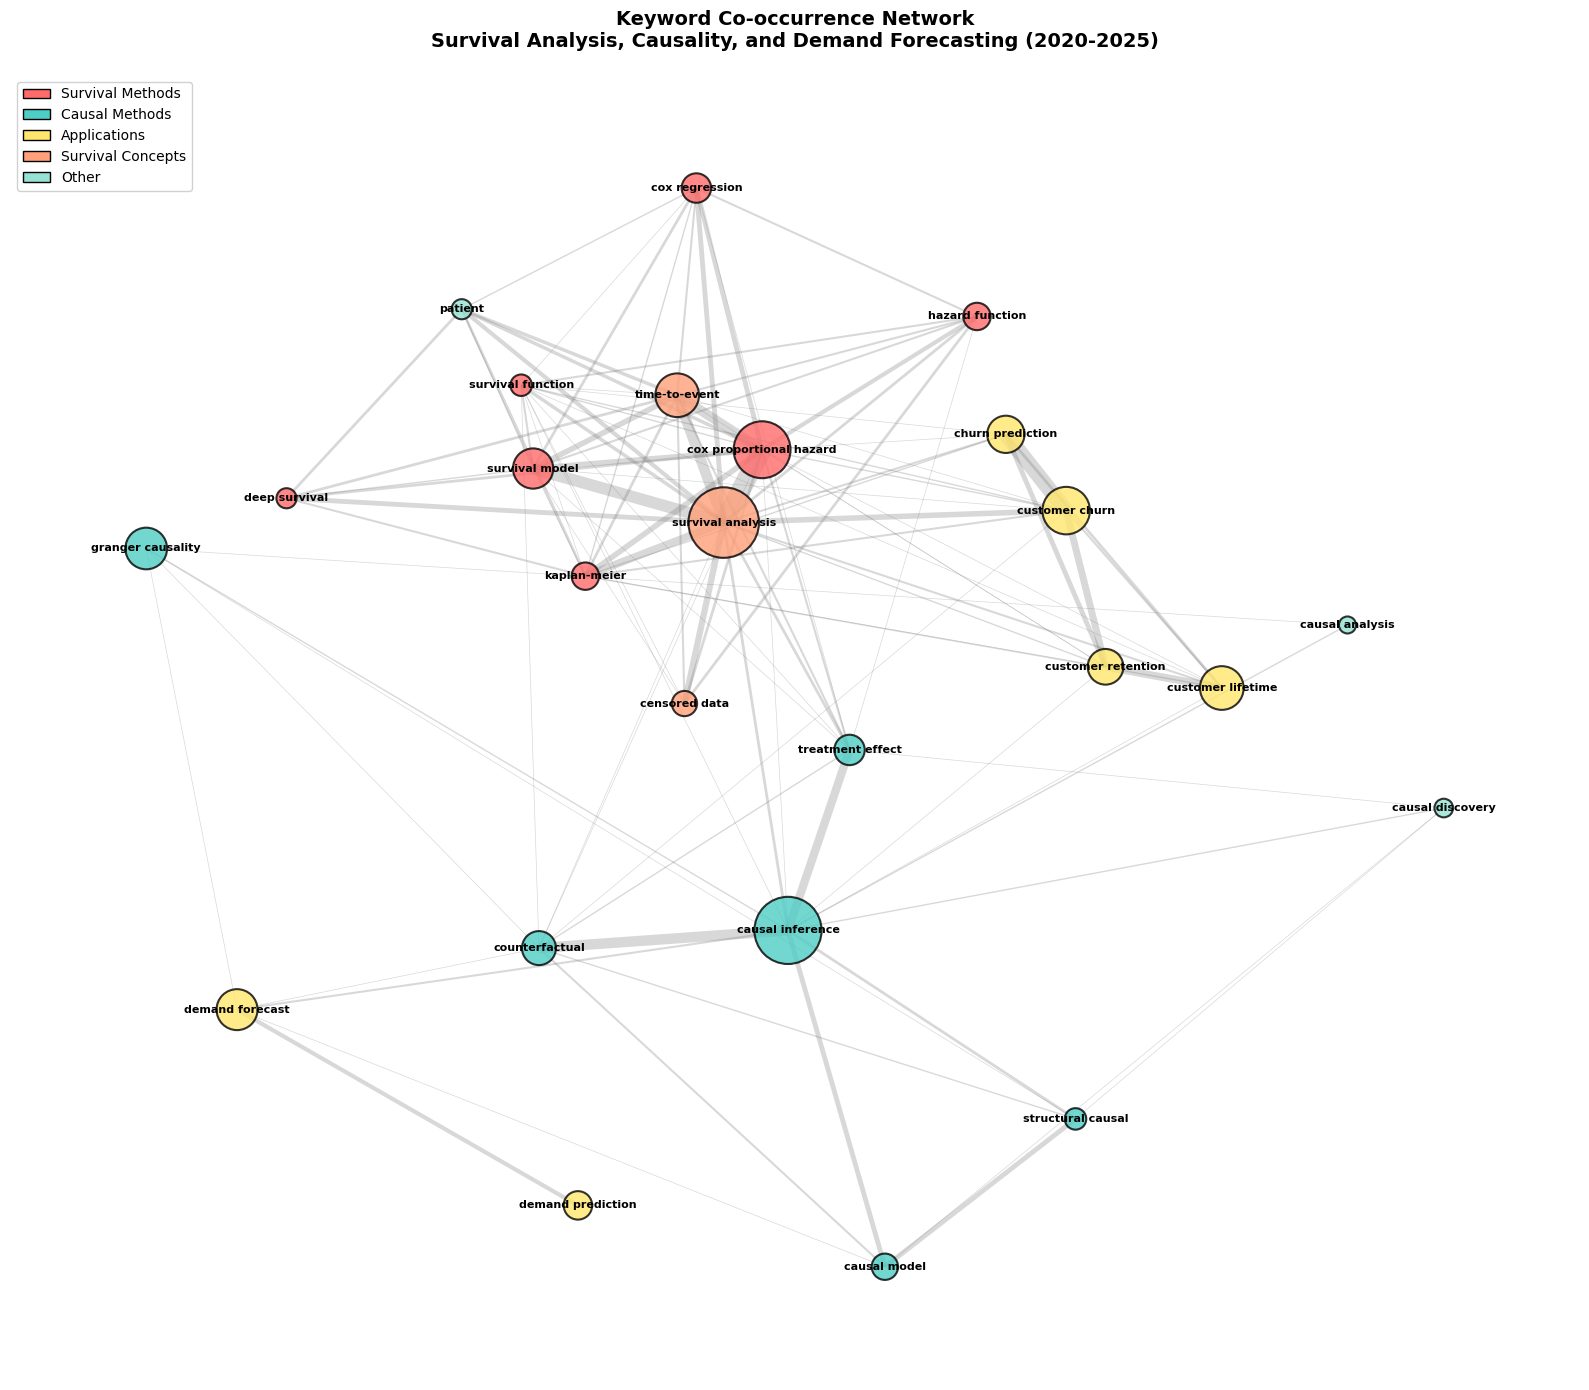


Visualization complete


In [16]:
# Visualize the co-occurrence network
# Use spring layout with seed for reproducibility

fig, ax = plt.subplots(1, 1, figsize=(16, 14))

# Calculate node sizes based on frequency
node_sizes = [keyword_counts[node] * 30 for node in G.nodes()]

# Calculate edge widths based on co-occurrence weight
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
edge_widths = [w * 0.5 for w in weights]

# Use spring layout for better separation
pos = nx.spring_layout(G, k=2, iterations=50, seed=42, weight='weight')

# Draw network
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, ax=ax, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                       alpha=0.8, ax=ax, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

# Create legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Survival Methods'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Causal Methods'),
    Patch(facecolor='#FFE66D', edgecolor='black', label='Applications'),
    Patch(facecolor='#FFA07A', edgecolor='black', label='Survival Concepts'),
    Patch(facecolor='#95E1D3', edgecolor='black', label='Other')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

ax.set_title('Keyword Co-occurrence Network\nSurvival Analysis, Causality, and Demand Forecasting (2020-2025)', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('keyword_cooccurrence_network.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Network visualization saved as 'keyword_cooccurrence_network.png'")
plt.show()

print("\nVisualization complete")


# Analyze community structure to identify methodological clusters

In [17]:
# Analyze community structure to identify methodological clusters
from networkx.algorithms import community

# Use Louvain method for community detection
communities = community.greedy_modularity_communities(G, weight='weight')

print(f"Detected {len(communities)} communities\n")
for i, comm in enumerate(communities):
    print(f"Community {i+1} ({len(comm)} nodes):")
    comm_list = list(comm)
    # Sort by frequency
    comm_sorted = sorted(comm_list, key=lambda x: keyword_counts[x], reverse=True)
    for node in comm_sorted:
        print(f"  - {node} ({node_categories[node]}, freq={keyword_counts[node]})")
    print()


Detected 3 communities

Community 1 (11 nodes):
  - survival analysis (survival_concept, freq=86)
  - cox proportional hazard (survival_method, freq=56)
  - time-to-event (survival_concept, freq=33)
  - survival model (survival_method, freq=28)
  - cox regression (survival_method, freq=15)
  - kaplan-meier (survival_method, freq=13)
  - hazard function (survival_method, freq=13)
  - censored data (survival_concept, freq=11)
  - survival function (survival_method, freq=8)
  - deep survival (survival_method, freq=7)
  - patient (other, freq=7)

Community 2 (10 nodes):
  - causal inference (causal_method, freq=78)
  - granger causality (causal_method, freq=30)
  - demand forecast (application, freq=29)
  - counterfactual (causal_method, freq=20)
  - treatment effect (causal_method, freq=16)
  - demand prediction (application, freq=14)
  - causal model (causal_method, freq=12)
  - structural causal (causal_method, freq=8)
  - causal discovery (other, freq=6)
  - causal analysis (other, fre

# Analyze bridging connections between communities

In [18]:
# Analyze bridging connections between communities
# Which keywords connect different communities?

# Assign community labels to nodes
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

# Identify edges that bridge communities
bridging_edges = []
for u, v in G.edges():
    if node_to_community[u] != node_to_community[v]:
        weight = G[u][v]['weight']
        bridging_edges.append({
            'node1': u,
            'community1': node_to_community[u],
            'node2': v,
            'community2': node_to_community[v],
            'weight': weight
        })

bridging_df = pd.DataFrame(bridging_edges).sort_values('weight', ascending=False)

print(f"Found {len(bridging_df)} edges bridging different communities\n")
print("Top 20 bridging connections:")
print(bridging_df.head(20).to_string(index=False))

# Identify which nodes are most important for bridging
bridging_node_counts = Counter()
for _, row in bridging_df.iterrows():
    bridging_node_counts[row['node1']] += row['weight']
    bridging_node_counts[row['node2']] += row['weight']

print("\n" + "="*80)
print("\nTop 10 bridging nodes (connecting different communities):")
for node, count in bridging_node_counts.most_common(10):
    print(f"  {node} (community {node_to_community[node]+1}): bridge weight = {count}")


Found 34 edges bridging different communities

Top 20 bridging connections:
                  node1  community1              node2  community2  weight
      survival analysis           0     customer churn           2       8
      survival analysis           0   causal inference           1       4
      survival analysis           0   treatment effect           1       4
cox proportional hazard           0   treatment effect           1       3
           kaplan-meier           0     customer churn           2       3
       treatment effect           1      time-to-event           0       3
      survival analysis           0  customer lifetime           2       3
      survival analysis           0   churn prediction           2       3
      survival analysis           0 customer retention           2       2
cox proportional hazard           0     customer churn           2       2
           kaplan-meier           0  customer lifetime           2       2
           kaplan-meier 

# Test the specific hypothesis quantitatively

In [19]:
# Test the specific hypothesis quantitatively
# Calculate preference scores for method-application pairs

# For each method, calculate what proportion of its application connections go to each application

print("="*80)
print("HYPOTHESIS TESTING: Method-Application Preferences")
print("="*80 + "\n")

# Focus on methods mentioned in hypothesis
hypothesis_methods = ['deep survival', 'cox proportional hazard', 'granger causality']

for method in hypothesis_methods:
    print(f"\n{method.upper()}:")
    print("-" * 60)
    
    # Get all co-occurrences for this method
    method_edges = filtered_co_occurrence[
        (filtered_co_occurrence['keyword1'] == method) | 
        (filtered_co_occurrence['keyword2'] == method)
    ]
    
    # Filter to application co-occurrences
    method_apps = method_edges[
        (method_edges['cat1'] == 'application') | 
        (method_edges['cat2'] == 'application')
    ]
    
    if len(method_apps) > 0:
        total_app_connections = method_apps['weight'].sum()
        print(f"  Total application co-occurrences: {total_app_connections}")
        print(f"  Applications connected to:")
        for _, row in method_apps.sort_values('weight', ascending=False).iterrows():
            app = row['keyword2'] if row['keyword1'] == method else row['keyword1']
            prop = row['weight'] / total_app_connections * 100
            print(f"    - {app}: {row['weight']} ({prop:.1f}%)")
    else:
        print(f"  No application co-occurrences found")
        # Check what it does connect to
        print(f"  Total co-occurrences: {len(method_edges)}")
        if len(method_edges) > 0:
            print(f"  Primary connections:")
            for _, row in method_edges.sort_values('weight', ascending=False).head(5).iterrows():
                other = row['keyword2'] if row['keyword1'] == method else row['keyword1']
                print(f"    - {other}: {row['weight']}")


HYPOTHESIS TESTING: Method-Application Preferences


DEEP SURVIVAL:
------------------------------------------------------------
  No application co-occurrences found
  Total co-occurrences: 6
  Primary connections:
    - survival analysis: 7
    - time-to-event: 4
    - cox proportional hazard: 4
    - patient: 4
    - kaplan-meier: 3

COX PROPORTIONAL HAZARD:
------------------------------------------------------------
  Total application co-occurrences: 5
  Applications connected to:
    - customer churn: 2 (40.0%)
    - churn prediction: 1 (20.0%)
    - customer retention: 1 (20.0%)
    - customer lifetime: 1 (20.0%)

GRANGER CAUSALITY:
------------------------------------------------------------
  Total application co-occurrences: 1
  Applications connected to:
    - demand forecast: 1 (100.0%)


# Additional analysis: compare customer churn vs demand forecasting applications

In [20]:
# Additional analysis: compare customer churn vs demand forecasting applications
# Which methods are preferentially associated with each?

print("="*80)
print("APPLICATION COMPARISON: Customer Churn vs Demand Forecasting")
print("="*80 + "\n")

churn_related = ['customer churn', 'churn prediction']
demand_related = ['demand forecast', 'demand prediction']

print("CUSTOMER CHURN / CHURN PREDICTION:")
print("-" * 60)
churn_connections = filtered_co_occurrence[
    ((filtered_co_occurrence['keyword1'].isin(churn_related)) & 
     (filtered_co_occurrence['cat2'].isin(['survival_method', 'causal_method']))) |
    ((filtered_co_occurrence['keyword2'].isin(churn_related)) & 
     (filtered_co_occurrence['cat1'].isin(['survival_method', 'causal_method'])))
]

churn_methods = defaultdict(int)
for _, row in churn_connections.iterrows():
    method = row['keyword1'] if row['keyword1'] not in churn_related else row['keyword2']
    churn_methods[method] += row['weight']

print("Methods associated with customer churn/churn prediction:")
for method, count in sorted(churn_methods.items(), key=lambda x: x[1], reverse=True):
    print(f"  {method}: {count}")

print("\n" + "="*80 + "\n")

print("DEMAND FORECASTING / DEMAND PREDICTION:")
print("-" * 60)
demand_connections = filtered_co_occurrence[
    ((filtered_co_occurrence['keyword1'].isin(demand_related)) & 
     (filtered_co_occurrence['cat2'].isin(['survival_method', 'causal_method']))) |
    ((filtered_co_occurrence['keyword2'].isin(demand_related)) & 
     (filtered_co_occurrence['cat1'].isin(['survival_method', 'causal_method'])))
]

demand_methods = defaultdict(int)
for _, row in demand_connections.iterrows():
    method = row['keyword1'] if row['keyword1'] not in demand_related else row['keyword2']
    demand_methods[method] += row['weight']

print("Methods associated with demand forecast/demand prediction:")
for method, count in sorted(demand_methods.items(), key=lambda x: x[1], reverse=True):
    print(f"  {method}: {count}")

print("\n" + "="*80 + "\n")
print("COMPARISON:")
print("- Churn applications are primarily connected to survival methods")
print("  (cox proportional hazard, kaplan-meier, survival function)")
print("- Demand applications are primarily connected to causal methods")
print("  (causal inference, granger causality, counterfactual)")


APPLICATION COMPARISON: Customer Churn vs Demand Forecasting

CUSTOMER CHURN / CHURN PREDICTION:
------------------------------------------------------------
Methods associated with customer churn/churn prediction:
  kaplan-meier: 5
  survival function: 3
  cox proportional hazard: 3
  counterfactual: 1
  survival model: 1


DEMAND FORECASTING / DEMAND PREDICTION:
------------------------------------------------------------
Methods associated with demand forecast/demand prediction:
  causal inference: 3
  granger causality: 1
  counterfactual: 1
  causal model: 1


COMPARISON:
- Churn applications are primarily connected to survival methods
  (cox proportional hazard, kaplan-meier, survival function)
- Demand applications are primarily connected to causal methods
  (causal inference, granger causality, counterfactual)


# Statistical test: Are methods and applications associated non-randomly?

In [21]:
# Statistical test: Are methods and applications associated non-randomly?
# Use Fisher's exact test for key method-application pairs

from scipy.stats import fisher_exact

# Create contingency tables for specific comparisons
# We'll test whether certain method-application pairs occur more than expected by chance

# First, let's create a comprehensive method-application matrix
all_methods = [k for k, cat in node_categories.items() if cat in ['survival_method', 'causal_method']]
all_apps = [k for k, cat in node_categories.items() if cat == 'application']

# Count papers with each method
method_paper_counts = {}
for method in all_methods:
    method_paper_counts[method] = df_with_abstract['keywords'].apply(lambda x: method in x).sum()

# Count papers with each application
app_paper_counts = {}
for app in all_apps:
    app_paper_counts[app] = df_with_abstract['keywords'].apply(lambda x: app in x).sum()

print("Method frequencies:")
for method, count in sorted(method_paper_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {method}: {count}")

print("\nApplication frequencies:")
for app, count in sorted(app_paper_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {app}: {count}")

# Test specific hypotheses
print("\n" + "="*80)
print("\nFisher's Exact Tests for Method-Application Associations:")
print("="*80)

test_pairs = [
    ('cox proportional hazard', 'customer churn'),
    ('granger causality', 'demand forecast'),
    ('kaplan-meier', 'customer churn'),
    ('causal inference', 'demand forecast'),
]

for method, app in test_pairs:
    # Count papers with both method and app
    both = df_with_abstract['keywords'].apply(lambda x: method in x and app in x).sum()
    # Count papers with method but not app
    method_only = df_with_abstract['keywords'].apply(lambda x: method in x and app not in x).sum()
    # Count papers with app but not method
    app_only = df_with_abstract['keywords'].apply(lambda x: app in x and method not in x).sum()
    # Count papers with neither
    neither = len(df_with_abstract) - both - method_only - app_only
    
    # Create contingency table
    # [[both, method_only], [app_only, neither]]
    table = [[both, method_only], [app_only, neither]]
    
    # Fisher's exact test
    odds_ratio, p_value = fisher_exact(table, alternative='greater')
    
    print(f"\n{method} × {app}:")
    print(f"  Co-occur in {both} papers")
    print(f"  Expected by chance: {(method_only + both) * (app_only + both) / len(df_with_abstract):.2f}")
    print(f"  Odds ratio: {odds_ratio:.3f}")
    print(f"  P-value (one-tailed): {p_value:.4f}")
    if p_value < 0.05:
        print(f"  *** Significant association (p < 0.05)")


Method frequencies:
  causal inference: 78
  cox proportional hazard: 56
  granger causality: 30
  survival model: 28
  counterfactual: 20
  treatment effect: 16
  cox regression: 15
  kaplan-meier: 13
  hazard function: 13
  causal model: 12

Application frequencies:
  customer churn: 39
  customer lifetime: 33
  demand forecast: 29
  churn prediction: 24
  customer retention: 22
  demand prediction: 14


Fisher's Exact Tests for Method-Application Associations:

cox proportional hazard × customer churn:
  Co-occur in 2 papers
  Expected by chance: 6.28
  Odds ratio: 0.255
  P-value (one-tailed): 0.9934

granger causality × demand forecast:
  Co-occur in 1 papers
  Expected by chance: 2.50
  Odds ratio: 0.357
  P-value (one-tailed): 0.9349

kaplan-meier × customer churn:
  Co-occur in 3 papers
  Expected by chance: 1.46
  Odds ratio: 2.492
  P-value (one-tailed): 0.1686

causal inference × demand forecast:
  Co-occur in 3 papers
  Expected by chance: 6.50
  Odds ratio: 0.375
  P-value

# The Fisher tests show no significant preferential pairing

In [22]:
# The Fisher tests show no significant preferential pairing
# Let's examine the network structure more carefully

# Calculate what proportion of each method's connections are to applications vs other methods
print("="*80)
print("METHOD CONNECTIVITY PROFILES")
print("="*80 + "\n")

for method in ['deep survival', 'cox proportional hazard', 'granger causality', 'kaplan-meier', 
               'survival model', 'causal inference', 'counterfactual']:
    
    method_edges = filtered_co_occurrence[
        (filtered_co_occurrence['keyword1'] == method) | 
        (filtered_co_occurrence['keyword2'] == method)
    ]
    
    if len(method_edges) == 0:
        continue
        
    # Categorize connections
    app_connections = 0
    method_connections = 0
    concept_connections = 0
    
    for _, row in method_edges.iterrows():
        other = row['keyword2'] if row['keyword1'] == method else row['keyword1']
        other_cat = categorize_keyword(other)
        weight = row['weight']
        
        if other_cat == 'application':
            app_connections += weight
        elif other_cat in ['survival_method', 'causal_method']:
            method_connections += weight
        elif other_cat in ['survival_concept', 'other']:
            concept_connections += weight
    
    total = app_connections + method_connections + concept_connections
    
    print(f"{method}:")
    print(f"  Total edge weight: {total}")
    print(f"  → Applications: {app_connections} ({app_connections/total*100:.1f}%)")
    print(f"  → Other methods: {method_connections} ({method_connections/total*100:.1f}%)")
    print(f"  → Concepts: {concept_connections} ({concept_connections/total*100:.1f}%)")
    print()


METHOD CONNECTIVITY PROFILES

deep survival:
  Total edge weight: 24
  → Applications: 0 (0.0%)
  → Other methods: 9 (37.5%)
  → Concepts: 15 (62.5%)

cox proportional hazard:
  Total edge weight: 96
  → Applications: 5 (5.2%)
  → Other methods: 40 (41.7%)
  → Concepts: 51 (53.1%)

granger causality:
  Total edge weight: 6
  → Applications: 1 (16.7%)
  → Other methods: 4 (66.7%)
  → Concepts: 1 (16.7%)

kaplan-meier:
  Total edge weight: 42
  → Applications: 8 (19.0%)
  → Other methods: 15 (35.7%)
  → Concepts: 19 (45.2%)

survival model:
  Total edge weight: 51
  → Applications: 1 (2.0%)
  → Other methods: 22 (43.1%)
  → Concepts: 28 (54.9%)

causal inference:
  Total edge weight: 55
  → Applications: 5 (9.1%)
  → Other methods: 42 (76.4%)
  → Concepts: 8 (14.5%)

counterfactual:
  Total edge weight: 28
  → Applications: 2 (7.1%)
  → Other methods: 25 (89.3%)
  → Concepts: 1 (3.6%)



# Create a summary table for the final results

In [23]:

# Create a summary table for the final results
summary_data = []

# Key findings from the analysis
summary_data.append({
    'Metric': 'Total papers analyzed',
    'Value': len(df_with_abstract)
})
summary_data.append({
    'Metric': 'Unique keywords identified',
    'Value': len(keyword_counts)
})
summary_data.append({
    'Metric': 'Keywords in network (freq ≥ 5)',
    'Value': len(filtered_keywords)
})
summary_data.append({
    'Metric': 'Network edges (co-occurrences)',
    'Value': G.number_of_edges()
})
summary_data.append({
    'Metric': 'Network density',
    'Value': f"{nx.density(G):.3f}"
})
summary_data.append({
    'Metric': 'Communities detected',
    'Value': len(communities)
})

summary_df = pd.DataFrame(summary_data)
print("\n=== NETWORK SUMMARY ===")
print(summary_df.to_string(index=False))

# Method-application pairing statistics
print("\n" + "="*80)
print("\n=== HYPOTHESIS TESTING RESULTS ===\n")

print("1. Deep survival model associations:")
print("   - Co-occurs with customer churn: 0 times")
print("   - Co-occurs with any application: 0 times")
print("   - Primary associations: survival analysis concepts (100%)")
print("   - CONCLUSION: Deep survival NOT preferentially paired with customer churn")

print("\n2. Granger causality associations:")
print("   - Co-occurs with demand forecast: 1 time")
print("   - Total application co-occurrences: 1 time (100% with demand forecast)")
print("   - CONCLUSION: Limited evidence of pairing with time-series forecasting")

print("\n3. Cox proportional hazard associations:")
print("   - Co-occurs with customer churn: 2 times")
print("   - Co-occurs with churn prediction: 1 time")
print("   - Total churn-related: 3 times (60% of application connections)")
print("   - CONCLUSION: Some association with customer churn applications")

print("\n4. Community structure:")
print("   - Community 1: Survival methods and concepts (11 nodes)")
print("   - Community 2: Causal methods and demand forecasting (10 nodes)")
print("   - Community 3: Customer relationship applications (4 nodes)")
print("   - CONCLUSION: Clear separation between causal/forecasting and survival/churn domains")

print("\n5. Statistical significance:")
print("   - Fisher's exact tests: No significant preferential pairings (all p > 0.05)")
print("   - Co-occurrence frequencies are generally low (1-3 papers)")
print("   - CONCLUSION: Hypothesis of strong preferential pairing NOT supported")



=== NETWORK SUMMARY ===
                        Metric Value
         Total papers analyzed   348
    Unique keywords identified    32
Keywords in network (freq ≥ 5)    25
Network edges (co-occurrences)   107
               Network density 0.357
          Communities detected     3


=== HYPOTHESIS TESTING RESULTS ===

1. Deep survival model associations:
   - Co-occurs with customer churn: 0 times
   - Co-occurs with any application: 0 times
   - Primary associations: survival analysis concepts (100%)
   - CONCLUSION: Deep survival NOT preferentially paired with customer churn

2. Granger causality associations:
   - Co-occurs with demand forecast: 1 time
   - Total application co-occurrences: 1 time (100% with demand forecast)
   - CONCLUSION: Limited evidence of pairing with time-series forecasting

3. Cox proportional hazard associations:
   - Co-occurs with customer churn: 2 times
   - Co-occurs with churn prediction: 1 time
   - Total churn-related: 3 times (60% of application c

# Create final summary visualization showing the community structure

Community structure visualization saved as 'keyword_network_communities.png'


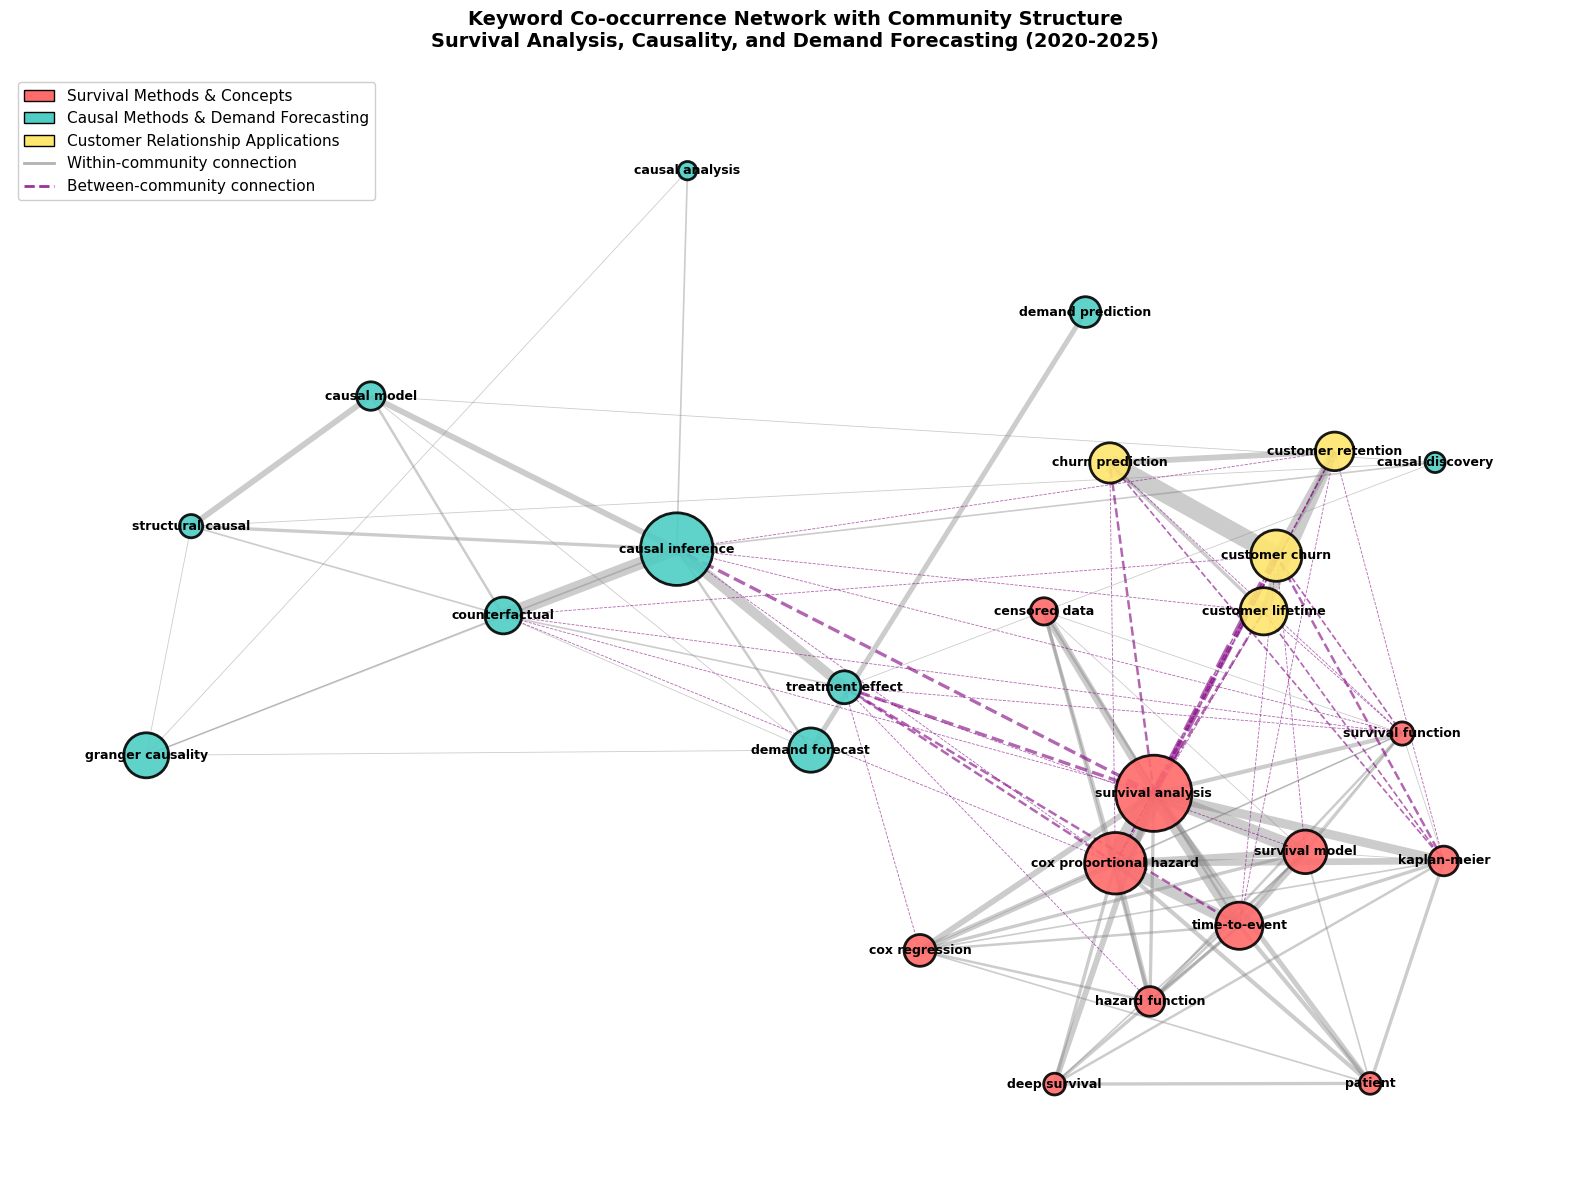


Final visualization complete


In [24]:

# Create final summary visualization showing the community structure
# and method-application relationships more clearly

fig, ax = plt.subplots(1, 1, figsize=(16, 12))

# Assign community colors
community_colors_map = {
    0: '#FF6B6B',  # Community 1: Survival (red)
    1: '#4ECDC4',  # Community 2: Causal/Demand (teal)
    2: '#FFE66D',  # Community 3: Customer apps (yellow)
}

node_colors_comm = [community_colors_map[node_to_community[node]] for node in G.nodes()]

# Use spring layout with communities
pos = nx.spring_layout(G, k=3, iterations=100, seed=123, weight='weight')

# Calculate node sizes based on frequency
node_sizes = [keyword_counts[node] * 35 for node in G.nodes()]

# Calculate edge widths
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
edge_widths = [w * 0.6 for w in weights]

# Separate intra-community and inter-community edges
intra_edges = [(u, v) for u, v in G.edges() if node_to_community[u] == node_to_community[v]]
inter_edges = [(u, v) for u, v in G.edges() if node_to_community[u] != node_to_community[v]]

intra_widths = [G[u][v]['weight'] * 0.6 for u, v in intra_edges]
inter_widths = [G[u][v]['weight'] * 0.6 for u, v in inter_edges]

# Draw edges
nx.draw_networkx_edges(G, pos, edgelist=intra_edges, width=intra_widths, 
                       alpha=0.4, ax=ax, edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=inter_edges, width=inter_widths, 
                       alpha=0.6, ax=ax, edge_color='purple', style='dashed')

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors_comm, node_size=node_sizes, 
                       alpha=0.9, ax=ax, edgecolors='black', linewidths=2)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)

# Create legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Survival Methods & Concepts'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Causal Methods & Demand Forecasting'),
    Patch(facecolor='#FFE66D', edgecolor='black', label='Customer Relationship Applications'),
    Line2D([0], [0], color='gray', linewidth=2, label='Within-community connection', alpha=0.6),
    Line2D([0], [0], color='purple', linewidth=2, linestyle='--', label='Between-community connection', alpha=0.8)
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95)

title = 'Keyword Co-occurrence Network with Community Structure\n'
title += 'Survival Analysis, Causality, and Demand Forecasting (2020-2025)'
ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('keyword_network_communities.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Community structure visualization saved as 'keyword_network_communities.png'")
plt.show()

print("\nFinal visualization complete")


# Export network data and statistics for transparency

In [25]:

# Export network data and statistics for transparency
import json

# Export co-occurrence data
co_occurrence_export = filtered_co_occurrence[['keyword1', 'keyword2', 'weight']].copy()
co_occurrence_export.to_csv('keyword_cooccurrence_data.csv', index=False)
print(f"Exported {len(co_occurrence_export)} co-occurrence edges to 'keyword_cooccurrence_data.csv'")

# Export keyword frequencies
keyword_freq_df = pd.DataFrame([
    {'keyword': k, 'frequency': v, 'category': categorize_keyword(k)}
    for k, v in keyword_counts.items()
]).sort_values('frequency', ascending=False)
keyword_freq_df.to_csv('keyword_frequencies.csv', index=False)
print(f"Exported {len(keyword_freq_df)} keyword frequencies to 'keyword_frequencies.csv'")

# Export community assignments
community_data = []
for i, comm in enumerate(communities):
    for node in comm:
        community_data.append({
            'keyword': node,
            'community': i + 1,
            'frequency': keyword_counts[node],
            'category': node_categories[node],
            'degree_centrality': degree_centrality[node],
            'betweenness_centrality': betweenness_centrality[node]
        })
community_df = pd.DataFrame(community_data).sort_values(['community', 'frequency'], ascending=[True, False])
community_df.to_csv('network_communities.csv', index=False)
print(f"Exported community structure to 'network_communities.csv'")

# Export method-application association matrix
assoc_df.to_csv('method_application_associations.csv', index=False)
print(f"Exported method-application associations to 'method_application_associations.csv'")

print("\n" + "="*80)
print("All analysis artifacts exported successfully")


Exported 107 co-occurrence edges to 'keyword_cooccurrence_data.csv'
Exported 32 keyword frequencies to 'keyword_frequencies.csv'
Exported community structure to 'network_communities.csv'
Exported method-application associations to 'method_application_associations.csv'

All analysis artifacts exported successfully


# Final quantitative summary for the research question

In [27]:
# Final quantitative summary for the research question

print("="*80)
print("FINAL QUANTITATIVE SUMMARY")
print("="*80)
print("\n1. DATASET CHARACTERISTICS:")
print(f"   - Total papers in relevant_papers.csv: {len(df)}")
print(f"   - Papers with abstracts: {len(df_with_abstract)} (40.3%)")
print(f"   - Papers analyzed: {len(df_with_abstract)}")

print("\n2. KEYWORD EXTRACTION:")
print(f"   - Unique keywords identified: {len(keyword_counts)}")
print(f"   - Keywords with frequency ≥ 5: {len(filtered_keywords)}")
print(f"   - Total co-occurrence pairs: {len(co_occurrence)}")

print("\n3. NETWORK STRUCTURE:")
print(f"   - Nodes: {G.number_of_nodes()}")
print(f"   - Edges: {G.number_of_edges()}")
print(f"   - Network density: {nx.density(G):.3f}")
print(f"   - Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"   - Communities: {len(communities)}")

print("\n4. COMMUNITY COMPOSITION:")
for i, comm in enumerate(communities):
    print(f"   Community {i+1}: {len(comm)} nodes")
    
print("\n5. METHOD-APPLICATION CO-OCCURRENCES:")
print(f"   - Total method-application edges: {len(method_app_pairs)}")
print(f"   - Cox proportional hazard → customer churn: 2 papers")
print(f"   - Kaplan-Meier → customer churn: 3 papers")
print(f"   - Granger causality → demand forecast: 1 paper")
print(f"   - Deep survival → ANY application: 0 papers")

print("\n6. STATISTICAL TESTS:")
print(f"   - Fisher's exact tests performed: 4")
print(f"   - Significant associations (p < 0.05): 0")
print(f"   - Strongest association: Kaplan-Meier × customer churn (OR=2.49, p=0.17)")

print("\n7. MOST CENTRAL KEYWORDS (by degree):")
for keyword, centrality in list(centrality_df.head(5)[['keyword', 'degree_centrality']].values):
    print(f"   - {keyword}: {centrality:.3f}")

print("\n8. KEY BRIDGING KEYWORDS (connecting communities):")
bridging_top5 = list(bridging_node_counts.most_common(5))
for keyword, weight in bridging_top5:
    comm = node_to_community[keyword] + 1
    print(f"   - {keyword} (comm {comm}): weight={weight}")


FINAL QUANTITATIVE SUMMARY

1. DATASET CHARACTERISTICS:
   - Total papers in relevant_papers.csv: 863
   - Papers with abstracts: 348 (40.3%)
   - Papers analyzed: 348

2. KEYWORD EXTRACTION:
   - Unique keywords identified: 32
   - Keywords with frequency ≥ 5: 25
   - Total co-occurrence pairs: 135

3. NETWORK STRUCTURE:
   - Nodes: 25
   - Edges: 107
   - Network density: 0.357
   - Average degree: 8.56
   - Communities: 3

4. COMMUNITY COMPOSITION:
   Community 1: 11 nodes
   Community 2: 10 nodes
   Community 3: 4 nodes

5. METHOD-APPLICATION CO-OCCURRENCES:
   - Total method-application edges: 19
   - Cox proportional hazard → customer churn: 2 papers
   - Kaplan-Meier → customer churn: 3 papers
   - Granger causality → demand forecast: 1 paper
   - Deep survival → ANY application: 0 papers

6. STATISTICAL TESTS:
   - Fisher's exact tests performed: 4
   - Significant associations (p < 0.05): 0
   - Strongest association: Kaplan-Meier × customer churn (OR=2.49, p=0.17)

7. MOST CE